# 3b. SBI Model Comparison: BE vs SC

**Purpose**: Can SBI-based model comparison classify animals as BE or SC?
Three approaches, compared for agreement.

| Part | Sessions | Fitting target | Training | Cost |
|------|----------|---------------|----------|------|
| **1** | Expert only | Broad stats (amortised SNPE) → predict UM | Once | ~1h |
| **2** | Expert only | Stats + UM (per-animal SNPE) | Per animal | ~20min/animal |
| **3** | All sessions | Broad stats (amortised SNPE) → predict UM | Once | ~1h |

**Protocol** (all parts):
1. Train SNPE posterior (amortised or per-animal)
2. Condition on observed stats → posterior over params
3. 2-fold CV × 64 repeats: sample params → simulate → compute UM → MSE
4. ANOVA on BE vs SC test error distributions

**Important**: The CV splitting is block-level (sessions), preserving
trial order within folds. The original trial-level splitting was a bug
that destroyed sequential structure — all results here use the fixed version.

**Checkpointing**: Each part saves results to pickle. Re-running the
notebook loads from checkpoint if available.

---

**⚠ Reliability note:** SBI-based model comparison on synthetic data
classified all animals as SC, regardless of the true generative model.
This indicates the SBI approach is unreliable for BE/SC model selection.
Grid-search CV on the update matrix (notebook 3a) is the validated
approach. This notebook is retained as a record and for cases where
SBI results may complement grid-search, but its classifications should
not be trusted in isolation.

---

## 0. Setup

In [1]:
from shared_setup import *

import pickle

from behav_utils.plotting.styles import apply_style
apply_style()

# Check SBI availability
SBI_OK = False
try:
    import torch
    from sbi.inference import SNPE
    SBI_OK = True
    print(f'SBI available (torch={torch.__version__})')
except ImportError as e:
    print(f'SBI not available: {e}')

# Inference comparison pipeline
from inference.comparison import (
    select_expert_fitting_data, select_all_fitting_data,
    train_amortised_snpe, compare_models,
    run_animal_pipeline, run_animal_pipeline_part2,
    simulate_all_sessions,
    estimate_timing, print_timing_report,
)

# Plotting
from plotting.comparison import (
    plot_sbi_cv_comparison, plot_pooled_um_comparison,
)

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


SBI available (torch=2.5.1)


In [2]:
CONFIG_PATH = PATH_CONFIG
RESULTS_DIR = Path('../results/sbi')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Quick mode: small-scale run for pipeline validation ─────────────────────
QUICK = True   # True = fast validation; False = full-scale (cluster)

# Session selection
DISTRIBUTION = 'Uniform'
EXPERT_MIN_ACCURACY = 0.70
EXPERT_LAST_FRACTION = 0.50
MIN_VALID_TRIALS = 30

# Stats
SBI_STATS = [
    'accuracy', 'psychometric', 'recency', 'stimulus_recency',
    'win_stay', 'lose_shift', 'side_bias', 'stimulus_sensitivity',
    'choice_entropy', 'perseveration',
]
SBI_STATS_WITH_UM = SBI_STATS + ['update_matrix']

# SBI config — scales with QUICK
if QUICK:
    N_SBI_SIMS = 1_000
    N_SBI_SIMS_P2 = 500
    N_GENERIC_TRIALS = 300
    N_CV_REPEATS = 4
    MAX_ANIMALS = 2
    EXPERT_BURN_IN = 500
    FULL_BURN_IN = 500
    print('QUICK mode: reduced sims for pipeline validation')
else:
    N_SBI_SIMS = 50_000
    N_SBI_SIMS_P2 = 10_000
    N_GENERIC_TRIALS = 2500
    N_CV_REPEATS = 64
    MAX_ANIMALS = None
    EXPERT_BURN_IN = 1000
    FULL_BURN_IN = 1000

SEED = 42

QUICK mode: reduced sims for pipeline validation


In [3]:
experiment, load_info = load_data()
animals = experiment.get_animals(min_sessions=10, stage=STAGE)
if MAX_ANIMALS is not None:
    animals = animals[:MAX_ANIMALS]
print(f'{len(animals)} animals')

# Quick timing estimate
if SBI_OK:
    timing = estimate_timing(
        stat_names=SBI_STATS,
        n_trials=N_GENERIC_TRIALS,
        burn_in=EXPERT_BURN_IN,
        n_sbi_sims=N_SBI_SIMS,
    )
    print_timing_report(timing, n_sbi_sims=N_SBI_SIMS, n_animals=len(animals))

Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV
2 animals

  1,000 simulations
  Model    ms/sim      Total   NaN%  θ dims  Stat dims
  --------------------------------------------------
  BE           81       1min   20%       4         13
  SC          133       2min    0%       4         13

  2 animals × 2 models = ~0 hours total


## Helper: Summarise and Plot One Part

Shared code for all three parts — avoids triplication.

In [4]:
def summarise_part(results, part_label):
    """Build summary table and print/plot for one part."""
    if not results:
        print(f'{part_label}: no results')
        return pd.DataFrame()

    rows = []
    for r in results:
        rows.append({
            'animal_id': r['animal_id'],
            'n_sessions': r['n_sessions'],
            'n_trials': r['n_trials'],
            'winner': r['winner'],
            'p_value': r['p'],
            'be_mean': r['be_mean'],
            'sc_mean': r['sc_mean'],
        })
    df = pd.DataFrame(rows)

    print(f'\n=== {part_label} ===')
    print(df[['animal_id', 'be_mean', 'sc_mean', 'p_value', 'winner']].to_string(index=False))

    n_be = (df['winner'] == 'BE').sum()
    n_sc = (df['winner'] == 'SC').sum()
    n_ns = (df['winner'] == 'NS').sum()
    print(f'\nBE: {n_be}, SC: {n_sc}, NS: {n_ns}')

    return df


def plot_part(results, part_label):
    """CV comparison plots for all animals in one part."""
    for r in results:
        comp = compare_models(r['be_cv'], r['sc_cv'])
        fig = plot_sbi_cv_comparison(
            r['be_cv'], r['sc_cv'], comp,
            r['animal_id'], f'({part_label})',
        )
        plt.show()
        plt.close(fig)


def save_part(results, filename):
    """Save results, stripping non-serialisable objects."""
    # Strip CV detail arrays to keep pickle small
    save_data = []
    for r in results:
        save_r = {k: v for k, v in r.items()
                  if k not in ('be_cv', 'sc_cv')}
        # Keep just the summary stats from CV
        for model in ('be', 'sc'):
            cv_key = f'{model}_cv'
            if cv_key in r and r[cv_key] is not None:
                save_r[f'{model}_cv_errors'] = r[cv_key].get('test_errors', [])
        save_data.append(save_r)

    path = RESULTS_DIR / filename
    with open(path, 'wb') as f:
        pickle.dump(save_data, f)
    print(f'Saved to {path}')


def load_part(filename):
    """Load saved results. Returns list or None."""
    path = RESULTS_DIR / filename
    if path.exists():
        with open(path, 'rb') as f:
            data = pickle.load(f)
        print(f'Loaded {len(data)} results from {path}')
        return data
    return None

---
## Part 1: Amortised SNPE on Expert Sessions

Train one SNPE network per model using generic Uniform stimuli.
Then condition on each animal's observed stats and run CV.

**Advantage**: fast per-animal (training is amortised).
**Limitation**: stats exclude update matrix (sequence-dependent).

In [5]:
p1 = load_part('sbi_part1.pkl')

if p1 is None and SBI_OK:
    # Train amortised networks
    print('Training amortised SNPE (Part 1)...')
    be_snpe_p1 = train_amortised_snpe(
        'be', SBI_STATS, N_SBI_SIMS, N_GENERIC_TRIALS,
        EXPERT_BURN_IN, SEED,
    )
    sc_snpe_p1 = train_amortised_snpe(
        'sc', SBI_STATS, N_SBI_SIMS, N_GENERIC_TRIALS,
        EXPERT_BURN_IN, SEED + 1,
    )

    # Run per-animal pipeline
    p1 = []
    for animal in animals:
        try:
            fd = select_expert_fitting_data(
                animal, STAGE, DISTRIBUTION,
                EXPERT_MIN_ACCURACY, EXPERT_LAST_FRACTION,
                MIN_VALID_TRIALS,
            )
            r = run_animal_pipeline(
                fd, be_snpe_p1, sc_snpe_p1,
                n_cv_repeats=N_CV_REPEATS, seed=SEED,
            )
            p1.append(r)
        except Exception as e:
            print(f'  {animal.animal_id}: SKIP — {e}')

    save_part(p1, 'sbi_part1.pkl')

Training amortised SNPE (Part 1)...

Training amortised SNPE [BE] (1,000 sims, 300 trials, burn_in=500)...
  Simulating...
  917/1000 valid (92%)
 Neural network successfully converged after 143 epochs.  Done in 1.5 min

Training amortised SNPE [SC] (1,000 sims, 300 trials, burn_in=500)...
  Simulating...
  992/1000 valid (99%)
 Training neural network. Epochs trained: 7

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [2] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 179 epochs.  Done in 2.1 min

  SS01: 10 sessions, 4984 trials


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

    CV: BE=0.01084 SC=0.00297 p=7.65e-05 → SC
Saved to ../results/sbi/sbi_part1.pkl



=== Part 1: Amortised SNPE (expert) ===
animal_id  be_mean  sc_mean  p_value winner
     SS01 0.004334 0.006099 0.001829     BE
     SS04 0.010842 0.002968 0.000076     SC

BE: 1, SC: 1, NS: 0


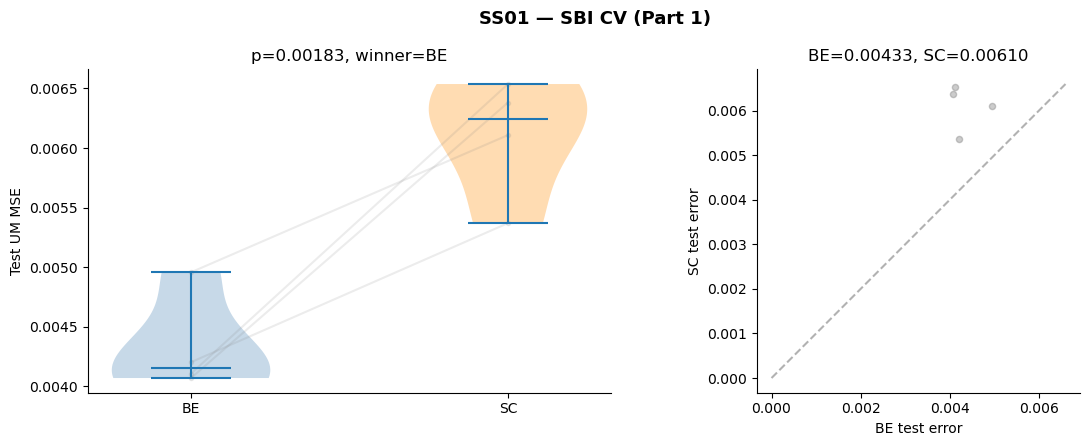

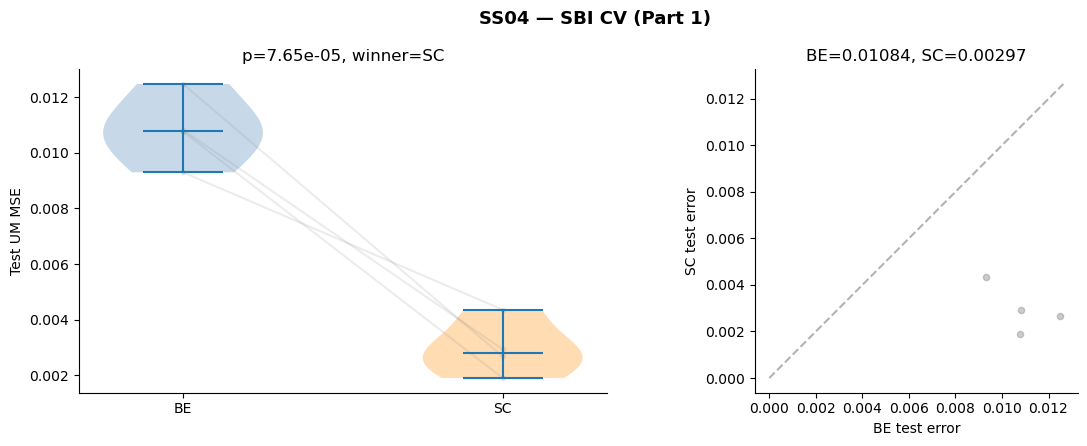

In [6]:
df_p1 = summarise_part(p1, 'Part 1: Amortised SNPE (expert)')
if p1:
    plot_part(p1, 'Part 1')

---
## Part 2: Per-Animal SNPE with UM (Expert Sessions)

Train a separate SNPE per animal using that animal's actual stimuli,
including the update matrix as a fitting target.

**Advantage**: UM is the discriminating statistic.
**Limitation**: expensive (one network per animal), smaller training set.

In [7]:
p2 = load_part('sbi_part2.pkl')

if p2 is None and SBI_OK:
    p2 = []
    for animal in animals:
        try:
            fd = select_expert_fitting_data(
                animal, STAGE, DISTRIBUTION,
                EXPERT_MIN_ACCURACY, EXPERT_LAST_FRACTION,
                MIN_VALID_TRIALS,
            )
            r = run_animal_pipeline_part2(
                fd, SBI_STATS_WITH_UM,
                n_sbi_sims=N_SBI_SIMS_P2,
                n_cv_repeats=N_CV_REPEATS,
                burn_in=EXPERT_BURN_IN, seed=SEED,
            )
            p2.append(r)
        except Exception as e:
            print(f'  {animal.animal_id}: SKIP — {e}')

    save_part(p2, 'sbi_part2.pkl')

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")



  SS01: 10 sessions, 4984 trials
  Training per-animal SNPE [BE] for SS01 (500 sims, 4984 trials)...
    494/500 valid (99%)
 Training neural network. Epochs trained: 12

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [2] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 122 epochs.    Done in 4.9 min
  Training per-animal SNPE [SC] for SS01 (500 sims, 4984 trials)...
    500/500 valid (100%)
 Training neural network. Epochs trained: 12

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [1] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

                    accepted. It may take a long time to collect the remaining
                    42 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


  0%|          | 0/50 [00:00<?, ?it/s]

    CV: BE=0.01156 SC=0.00347 p=7.22e-05 → SC
Saved to ../results/sbi/sbi_part2.pkl



=== Part 2: Per-animal SNPE with UM ===
animal_id  be_mean  sc_mean  p_value       winner
     SS01 0.005235 0.005206 0.907370 Inconclusive
     SS04 0.011555 0.003473 0.000072           SC

BE: 0, SC: 1, NS: 0


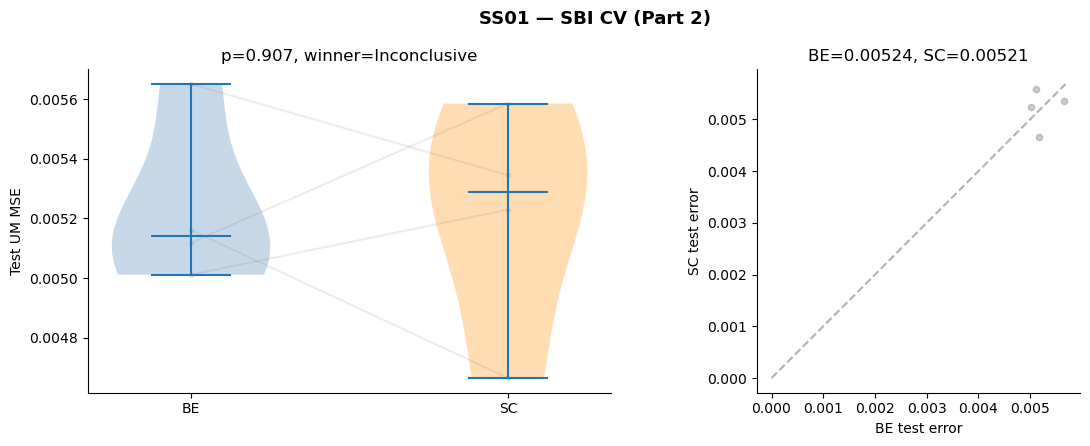

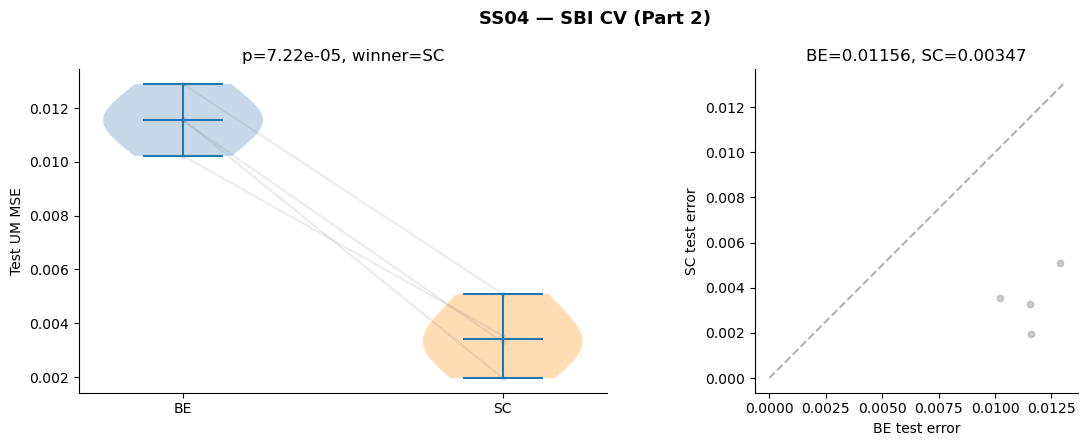

In [8]:
df_p2 = summarise_part(p2, 'Part 2: Per-animal SNPE with UM')
if p2:
    plot_part(p2, 'Part 2')

---
## Part 3: Amortised SNPE on All Sessions

Same as Part 1 but uses all qualifying sessions, not just expert.
More data per animal, but includes learning sessions where
parameters may not be stationary.

**Advantage**: more trials → better stat estimation.
**Limitation**: parameter non-stationarity during learning.

In [9]:
p3 = load_part('sbi_part3.pkl')

if p3 is None and SBI_OK:
    # Train with more trials (all sessions have more data)
    print('Training amortised SNPE (Part 3)...')
    be_snpe_p3 = train_amortised_snpe(
        'be', SBI_STATS, N_SBI_SIMS, 5000,
        FULL_BURN_IN, SEED + 10,
    )
    sc_snpe_p3 = train_amortised_snpe(
        'sc', SBI_STATS, N_SBI_SIMS, 5000,
        FULL_BURN_IN, SEED + 11,
    )

    p3 = []
    for animal in animals:
        try:
            fd = select_all_fitting_data(
                animal, STAGE, DISTRIBUTION, MIN_VALID_TRIALS,
            )
            r = run_animal_pipeline(
                fd, be_snpe_p3, sc_snpe_p3,
                n_cv_repeats=N_CV_REPEATS, seed=SEED,
            )
            p3.append(r)
        except Exception as e:
            print(f'  {animal.animal_id}: SKIP — {e}')

    save_part(p3, 'sbi_part3.pkl')

Training amortised SNPE (Part 3)...

Training amortised SNPE [BE] (1,000 sims, 5000 trials, burn_in=500)...
  Simulating...
  964/1000 valid (96%)
 Neural network successfully converged after 195 epochs.  Done in 8.3 min

Training amortised SNPE [SC] (1,000 sims, 5000 trials, burn_in=500)...
  Simulating...
  999/1000 valid (100%)
 Training neural network. Epochs trained: 4

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [1] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 192 epochs.  Done in 14.2 min

  SS01: 42 sessions, 20643 trials


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

    CV: BE=0.00773 SC=0.00188 p=1.26e-06 → SC
Saved to ../results/sbi/sbi_part3.pkl



=== Part 3: Amortised SNPE (all sessions) ===
animal_id  be_mean  sc_mean  p_value       winner
     SS01 0.007004 0.005702 0.498020 Inconclusive
     SS04 0.007734 0.001876 0.000001           SC

BE: 0, SC: 1, NS: 0


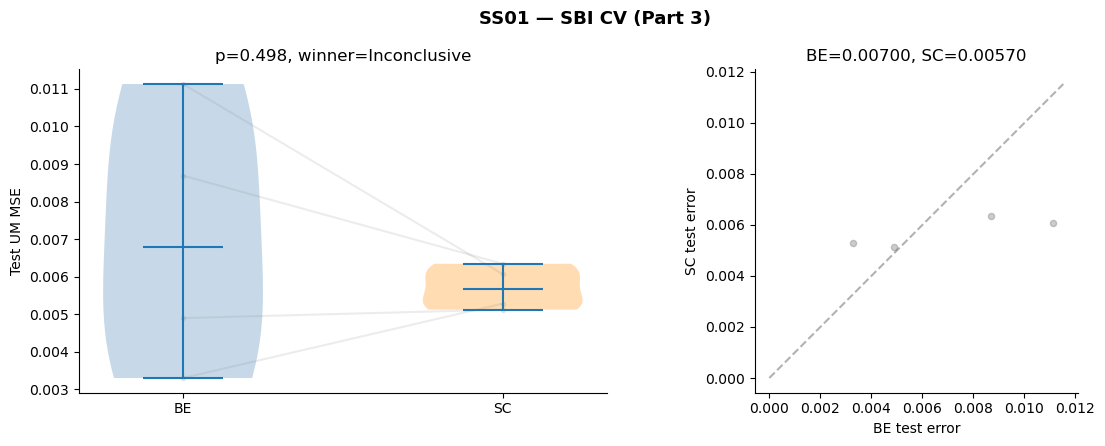

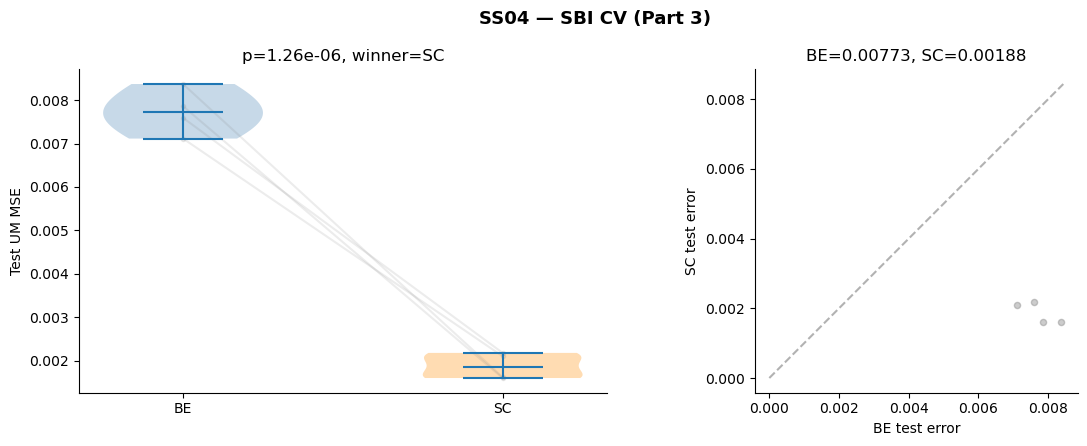

In [10]:
df_p3 = summarise_part(p3, 'Part 3: Amortised SNPE (all sessions)')
if p3:
    plot_part(p3, 'Part 3')

---
## 4. Cross-Part Comparison

Do the three approaches agree on which model wins per animal?

In [11]:
parts = {'P1_amortised_expert': df_p1,
         'P2_per_animal_UM': df_p2,
         'P3_amortised_all': df_p3}

# Only include parts that have results
parts = {k: v for k, v in parts.items() if len(v) > 0}

if len(parts) >= 2:
    # Merge on animal_id
    merged = None
    for label, df in parts.items():
        rename = df[['animal_id', 'winner']].rename(
            columns={'winner': label})
        if merged is None:
            merged = rename
        else:
            merged = merged.merge(rename, on='animal_id', how='outer')

    print('Model assignment per animal:\n')
    print(merged.to_string(index=False))

    # Pairwise agreement
    cols = [c for c in merged.columns if c != 'animal_id']
    print('\nPairwise agreement:')
    for i, c1 in enumerate(cols):
        for c2 in cols[i+1:]:
            both = merged.dropna(subset=[c1, c2])
            agree = (both[c1] == both[c2]).mean()
            print(f'  {c1} vs {c2}: {agree:.0%} ({len(both)} animals)')

    # Tallies per part
    print('\nTallies:')
    for col in cols:
        counts = merged[col].value_counts().to_dict()
        print(f'  {col}: {counts}')
else:
    print(f'Only {len(parts)} part(s) have results — need >=2 for comparison')

Model assignment per animal:

animal_id P1_amortised_expert P2_per_animal_UM P3_amortised_all
     SS01                  BE     Inconclusive     Inconclusive
     SS04                  SC               SC               SC

Pairwise agreement:
  P1_amortised_expert vs P2_per_animal_UM: 50% (2 animals)
  P1_amortised_expert vs P3_amortised_all: 50% (2 animals)
  P2_per_animal_UM vs P3_amortised_all: 100% (2 animals)

Tallies:
  P1_amortised_expert: {'BE': 1, 'SC': 1}
  P2_per_animal_UM: {'Inconclusive': 1, 'SC': 1}
  P3_amortised_all: {'Inconclusive': 1, 'SC': 1}


## 5. Visual Inspection: Session-by-Session Simulation

For each animal, simulate both models with their best-fit parameters
across all expert sessions. Compare simulated vs real update matrices
and psychometric curves.

Uses Part 1 results (amortised expert) as the default.

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


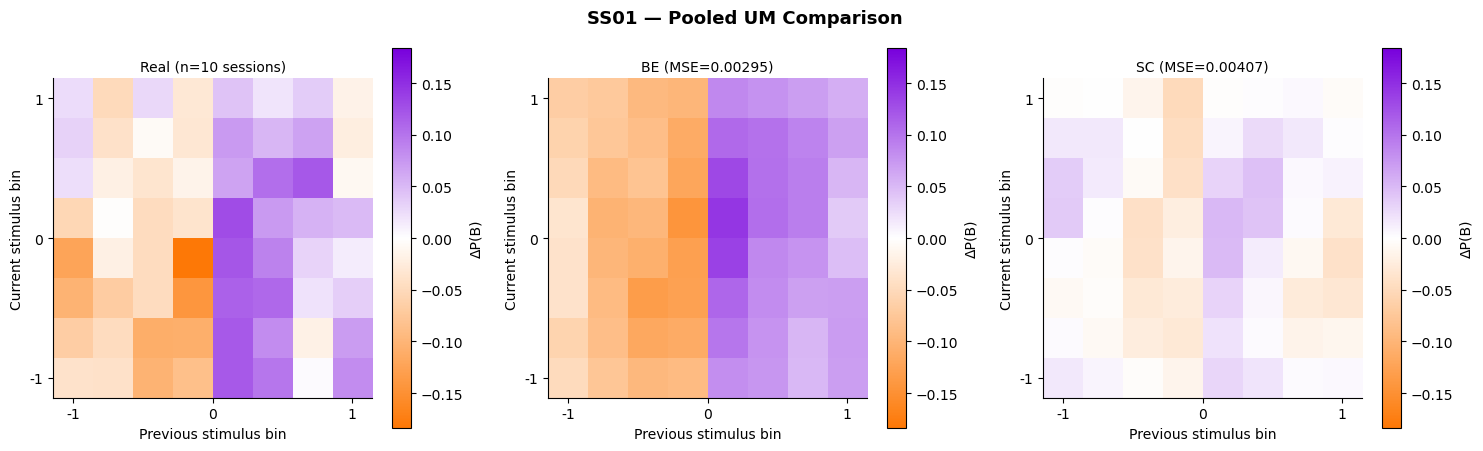

/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/behav_utils/data/structures.py:331: UserWarning: Only 0 valid trials — stats may be unreliable
  warnings.warn(f"Only {valid.sum()} valid trials — stats may be unreliable")


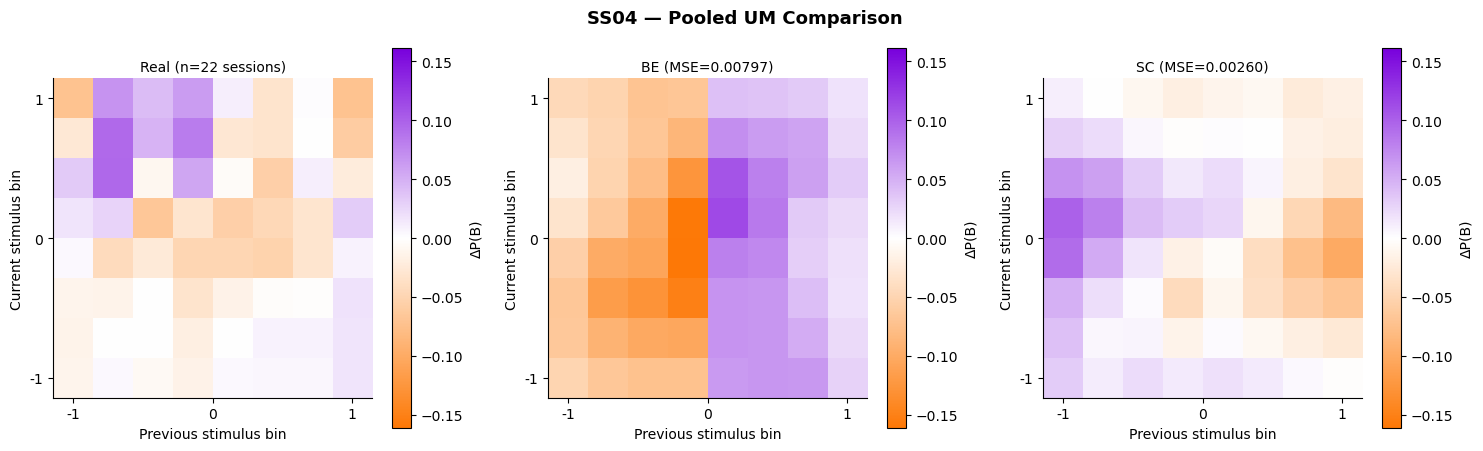

In [12]:
# Pick the best part's results for simulation
results_for_sim = p1 if p1 else (p2 if p2 else p3)

if results_for_sim:
    for r in results_for_sim:
        aid = r['animal_id']
        be_params = r.get('be_params', {})
        sc_params = r.get('sc_params', {})

        if not be_params or not sc_params:
            continue

        try:
            animal = experiment.get_animal(aid)
            fd = select_expert_fitting_data(
                animal, STAGE, DISTRIBUTION,
                EXPERT_MIN_ACCURACY, EXPERT_LAST_FRACTION,
                MIN_VALID_TRIALS,
            )

            session_data = simulate_all_sessions(
                fd, be_params, sc_params,
                burn_in=EXPERT_BURN_IN, seed=SEED,
            )

            # Pooled UM comparison
            fig = plot_pooled_um_comparison(session_data, aid)
            plt.show()
            plt.close(fig)

        except Exception as e:
            print(f'  {aid}: simulation failed — {e}')
else:
    print('No results available for simulation')

## 6. Save Final Comparison

In [13]:
# Save cross-part comparison table
if 'merged' in dir() and merged is not None:
    merged.to_csv(RESULTS_DIR / 'sbi_comparison_results.csv', index=False)
    print(f'Saved comparison to {RESULTS_DIR / "sbi_comparison_results.csv"}')

# Save combined results for notebook 3c
combined = {
    'p1': p1,
    'p2': p2,
    'p3': p3,
}
with open(RESULTS_DIR / 'sbi_comparison_results.pkl', 'wb') as f:
    pickle.dump(combined, f)
print(f'Saved to {RESULTS_DIR / "sbi_comparison_results.pkl"}')

Saved comparison to ../results/sbi/sbi_comparison_results.csv
Saved to ../results/sbi/sbi_comparison_results.pkl


## Interpretation

**If all three parts agree:** The SBI classification is robust across
different data subsets and training approaches.

**If Part 2 (with UM) differs from Parts 1/3 (without UM):**
Including the update matrix changes the classification. Since the UM
is the primary discriminating statistic, Part 2 may be more accurate —
but at the cost of per-animal training.

**If Part 3 (all sessions) differs from Part 1 (expert only):**
Learning-phase data changes the classification. This could mean:
(a) parameters are non-stationary during learning, violating the
static-parameter assumption, or (b) more data helps resolve an
ambiguous classification.

**Previous SC-dominance finding:** All animals were classified as SC
in earlier runs. This was caused by a trial-level CV bug that destroyed
sequential structure in the update matrix, flattening the BE win-stay
stripe. With the fixed block-level CV, results may differ substantially.

**Next**: notebook 3c compares SBI results with grid-search (3a).